In [2]:
import pandas as pd
import matplotlib.pyplot as plt

In [3]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [4]:
dataset=pd.read_csv('/content/drive/My Drive/Colab Notebooks/Datasets/lab_dataset.csv')

In [5]:
dataset.head()

,INCOME,SPEND
0,233,150
1,250,187
2,204,172
3,236,178
4,354,163


In [6]:
dataset.shape

(303, 2)

## finding best k

In [7]:
from sklearn.cluster import KMeans,AgglomerativeClustering

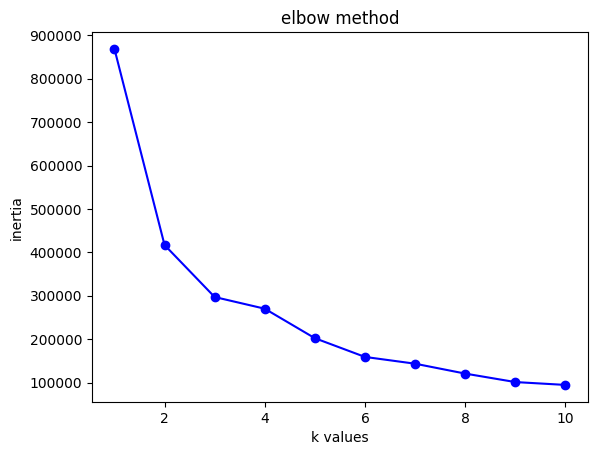

In [9]:
l=[]
for i in range(1,11):
  model=KMeans(n_clusters=i,random_state=1)
  model.fit(dataset)
  l.append(model.inertia_)

plt.plot(range(1,11),l,color='b',marker='o')
plt.xlabel("k values")
plt.ylabel('inertia')
plt.title('elbow method')
plt.show()


In [32]:
model=KMeans(n_clusters=3,random_state=1)
y_means=model.fit_predict(dataset)


In [33]:
labels=pd.DataFrame(model.labels_)
df=pd.concat([dataset,labels],axis=1)


In [34]:

df.head()

,INCOME,SPEND,0
0,233,150,2
1,250,187,2
2,204,172,0
3,236,178,2
4,354,163,1


In [35]:
df=df.rename(columns={0:"labels"})

<Axes: xlabel='INCOME', ylabel='SPEND'>

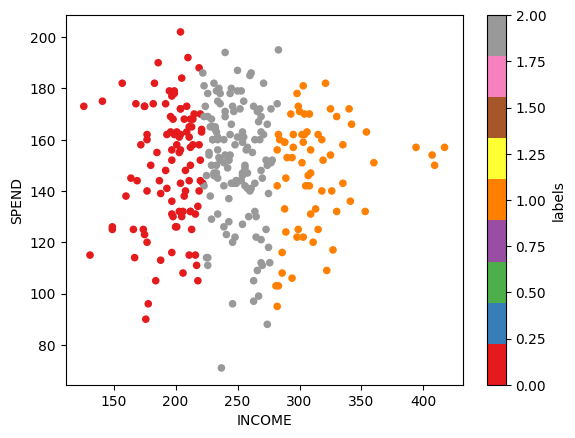

In [36]:
df.plot.scatter(x='INCOME',y='SPEND',c='labels',colormap='Set1')

# Using agglomarative clusting

<Axes: xlabel='INCOME', ylabel='SPEND'>

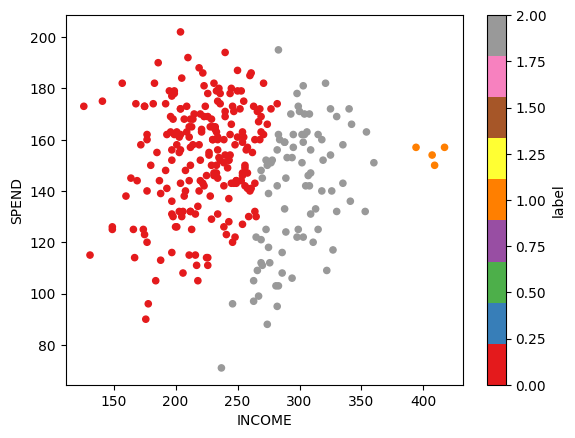

In [37]:
model1=AgglomerativeClustering(n_clusters=3,linkage='average')
label=model1.fit_predict(dataset)
label=pd.DataFrame(label)
df2=pd.concat([dataset,label],axis=1)
df2=df2.rename(columns={0:'label'})
df2.plot.scatter(x='INCOME',y='SPEND',c='label',colormap='Set1')
